# Compare Cell Statistics: GridRad NoFilter vs. Filtered

This notebook compares convective cell statistics between GridRad NoFilter vs. Filtered datasets over CONUS.

**Datasets:**
- NoFilter: `/pscratch/sd/i/iclas2/GridRad/cell_conus_nofilter/stats/cell_stats_20200401_20200831.parquet`
- Filter: `/pscratch/sd/i/iclas2/GridRad/cell_conus/stats/cell_stats_20200401_20200831.parquet`

**Analysis:**
1. Count number of cells per month on a gridded domain
2. Visualize and compare spatial distributions

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Optional: colormaps for better visualization
try:
    import colormaps as colormaps
except ImportError:
    print("Warning: colormaps not found. Using default colormaps.")
    colormaps = None

## Configuration

In [2]:
name_map = {'s1': 'NoFilter', 's2': 'Filtered'}

# File paths
file_s1 = '/pscratch/sd/i/iclas2/GridRad/cell_conus_nofilter/stats/cell_stats_20200401_20200831.parquet'
file_s2 = '/pscratch/sd/i/iclas2/GridRad/cell_conus/stats/cell_stats_20200401_20200831.parquet'

# Grid resolution (degrees)
grid_res_x = 1.0  # longitude
grid_res_y = 1.0  # latitude

# Map extent for CONUS [lon_min, lon_max, lat_min, lat_max]
map_extent = [235, 295, 25, 50]

# Map resolution
map_resolution = '50m'

figdir = '/global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/'
os.makedirs(figdir, exist_ok=True)

# Figure settings
dpi = 240
fontsize = 10

## Load Data

In [3]:
# Load s1 statistics
print(f"Loading {name_map['s1']} data...")
df_s1 = pd.read_parquet(file_s1)
print(f"{name_map['s1']}: {len(df_s1)} cells")
print(f"Columns: {df_s1.columns.tolist()}")
display(df_s1.head())

Loading NoFilter data...
NoFilter: 784276 cells
Columns: ['time', 'cell_id', 'filename', 'npixels', 'area', 'diameter', 'center_lon', 'center_lat', 'max_dbz_comp', 'max_dbz_lowlevel', 'max_echotop10', 'max_echotop20', 'max_echotop30', 'max_echotop40', 'max_echotop50']


,time,cell_id,filename,npixels,area,diameter,center_lon,center_lat,max_dbz_comp,max_dbz_lowlevel,max_echotop10,max_echotop20,max_echotop30,max_echotop40,max_echotop50
0,2020-04-01,1,cloudid_20200401_000000.nc,101,909.0,34.020211,277.522624,29.458781,50.575829,50.575829,15.0,10.0,7.0,5.5,2.5
1,2020-04-01,2,cloudid_20200401_000000.nc,43,387.0,22.197831,276.929016,29.279926,50.657604,NaN,12.0,10.0,7.0,5.5,2.5
2,2020-04-01,3,cloudid_20200401_000000.nc,41,369.0,21.675456,279.786289,30.548931,52.427479,52.427479,11.0,7.0,4.5,4.5,3.0
3,2020-04-01,4,cloudid_20200401_000000.nc,37,333.0,20.590988,278.239937,29.639731,49.363602,49.363602,12.0,8.0,6.5,5.0,NaN
4,2020-04-01,5,cloudid_20200401_000000.nc,31,279.0,18.847648,278.796885,29.465444,52.187092,52.187092,9.0,7.0,5.0,3.5,2.5


In [4]:
# Load s2 statistics
print(f"Loading {name_map['s2']} data...")
df_s2 = pd.read_parquet(file_s2)
print(f"{name_map['s2']}: {len(df_s2)} cells")
print(f"Columns: {df_s2.columns.tolist()}")
display(df_s2.head())

Loading Filtered data...
Filtered: 752703 cells
Columns: ['time', 'cell_id', 'filename', 'npixels', 'area', 'diameter', 'center_lon', 'center_lat', 'max_dbz_comp', 'max_dbz_lowlevel', 'max_echotop10', 'max_echotop20', 'max_echotop30', 'max_echotop40', 'max_echotop50']


,time,cell_id,filename,npixels,area,diameter,center_lon,center_lat,max_dbz_comp,max_dbz_lowlevel,max_echotop10,max_echotop20,max_echotop30,max_echotop40,max_echotop50
0,2020-04-01,1,cloudid_20200401_000000.nc,102,918.0,34.188213,277.521995,29.458188,50.575829,50.575829,12.0,10.0,7.0,5.5,3.5
1,2020-04-01,2,cloudid_20200401_000000.nc,46,414.0,22.959120,279.782382,30.554269,52.427479,52.427479,9.0,7.0,4.5,4.5,3.0
2,2020-04-01,3,cloudid_20200401_000000.nc,43,387.0,22.197831,276.929016,29.279926,50.657604,NaN,9.0,9.0,7.0,5.5,2.5
3,2020-04-01,4,cloudid_20200401_000000.nc,37,333.0,20.590988,278.239937,29.639731,49.363602,49.363602,11.0,8.0,6.5,5.0,NaN
4,2020-04-01,5,cloudid_20200401_000000.nc,31,279.0,18.847648,283.959318,33.708697,48.226025,48.226025,8.0,7.0,5.0,4.0,NaN


## Function: Count Cells on Grid by Month

In [5]:
def count_cells_monthly_grid(df, lon_col='meanlat', lat_col='meanlon', 
                             time_col='base_time',
                             grid_res_x=1.0, grid_res_y=1.0, 
                             lon_range=None, lat_range=None):
    """
    Count number of cells per month on a regular lat/lon grid.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Cell statistics dataframe containing cell center coordinates and time
    lon_col : str
        Column name for longitude (cell center)
    lat_col : str
        Column name for latitude (cell center)
    time_col : str
        Column name for time variable
    grid_res_x : float
        Grid resolution in longitude (degrees)
    grid_res_y : float
        Grid resolution in latitude (degrees)
    lon_range : tuple, optional
        Longitude range (min, max). If None, uses data extent.
    lat_range : tuple, optional
        Latitude range (min, max). If None, uses data extent.
    
    Returns:
    --------
    cell_counts : xr.DataArray
        Array with dimensions [month, lat, lon] containing cell counts
    """
    
    # Make a copy and ensure time column is datetime
    df_work = df.copy()
    
    # Convert time to datetime if needed
    if not pd.api.types.is_datetime64_any_dtype(df_work[time_col]):
        # Assume Unix timestamp if numeric
        df_work[time_col] = pd.to_datetime(df_work[time_col], unit='s')
    
    # Extract month
    df_work['month'] = df_work[time_col].dt.month
    
    # Determine lon/lat ranges
    if lon_range is None:
        lon_min = df_work[lon_col].min()
        lon_max = df_work[lon_col].max()
    else:
        lon_min, lon_max = lon_range
    
    if lat_range is None:
        lat_min = df_work[lat_col].min()
        lat_max = df_work[lat_col].max()
    else:
        lat_min, lat_max = lat_range
    
    # Create grid edges
    lon_edges = np.arange(lon_min, lon_max + grid_res_x, grid_res_x)
    lat_edges = np.arange(lat_min, lat_max + grid_res_y, grid_res_y)
    
    # Grid centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
    
    # Get unique months
    months = sorted(df_work['month'].unique())
    
    # Initialize counts array [month, lat, lon]
    cell_counts = np.zeros((len(months), len(lat_centers), len(lon_centers)))
    
    # Loop through months and count cells in each grid box
    for im, month in enumerate(months):
        df_month = df_work[df_work['month'] == month]
        
        # Bin cells into grid boxes
        counts, _, _ = np.histogram2d(
            df_month[lat_col], 
            df_month[lon_col],
            bins=[lat_edges, lon_edges]
        )
        
        cell_counts[im, :, :] = counts
    
    # Create xarray DataArray with coordinates
    cell_counts_da = xr.DataArray(
        cell_counts,
        coords={
            'month': months,
            'latitude': lat_centers,
            'longitude': lon_centers
        },
        dims=['month', 'latitude', 'longitude'],
        attrs={'long_name': 'Cell count', 'units': 'count'}
    )
    
    return cell_counts_da

## Count Cells on Grid

In [6]:
# Define grid domain based on map extent
lon_range = (map_extent[0], map_extent[1])
lat_range = (map_extent[2], map_extent[3])

# Count GridRad cells
print("Counting GridRad cells on grid...")
counts_s2 = count_cells_monthly_grid(
    df_s2, 
    lon_col='center_lon',  # Adjust based on actual column names
    lat_col='center_lat',  # Adjust based on actual column names
    time_col='time',
    grid_res_x=grid_res_x,
    grid_res_y=grid_res_y,
    lon_range=lon_range,
    lat_range=lat_range
)
print(f"GridRad counts shape: {counts_s2.shape}")
print(f"Months: {counts_s2.month.values}")

Counting GridRad cells on grid...
GridRad counts shape: (5, 25, 60)
Months: [4 5 6 7 8]


In [7]:
# Count SCREAM cells
print("Counting SCREAM cells on grid...")
counts_s1 = count_cells_monthly_grid(
    df_s1, 
    lon_col='center_lon',  # Adjust based on actual column names
    lat_col='center_lat',  # Adjust based on actual column names
    time_col='time',
    grid_res_x=grid_res_x,
    grid_res_y=grid_res_y,
    lon_range=lon_range,
    lat_range=lat_range
)
print(f"SCREAM counts shape: {counts_s1.shape}")
print(f"Months: {counts_s1.month.values}")

Counting SCREAM cells on grid...
SCREAM counts shape: (5, 25, 60)
Months: [4 5 6 7 8]


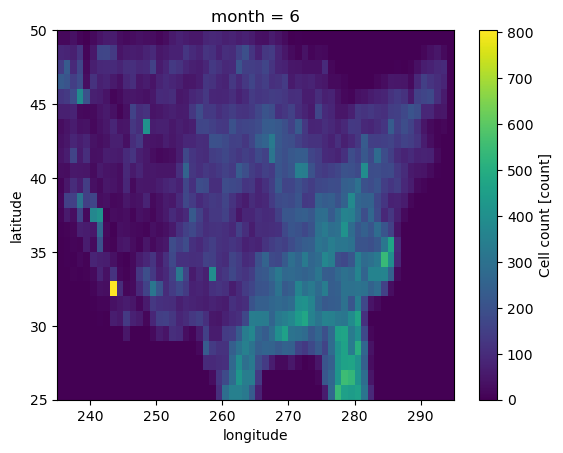

In [8]:
counts_s1.sel(month=6).plot()

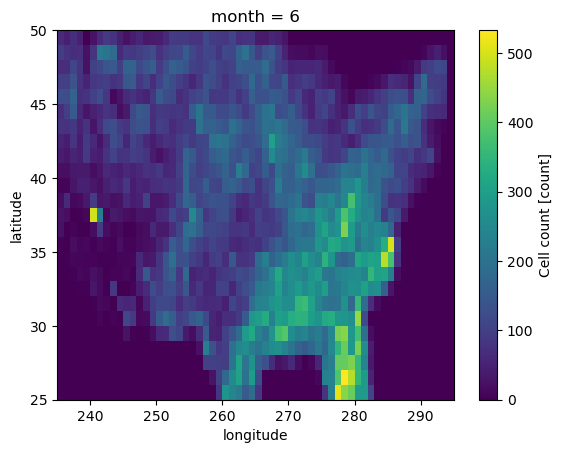

In [9]:
counts_s2.sel(month=6).plot()

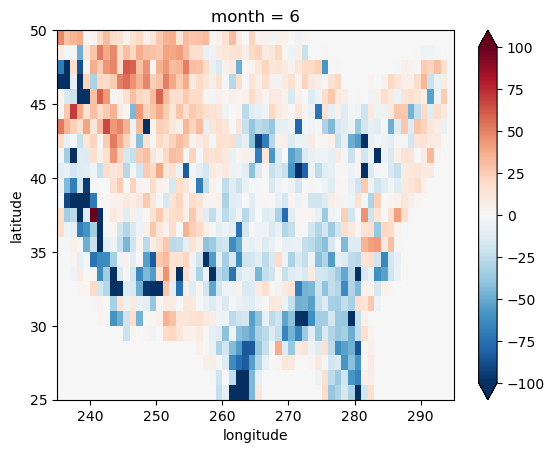

In [10]:
(counts_s2 - counts_s1).sel(month=6).plot(vmin=-100, vmax=100, cmap='RdBu_r')

## Function: Plot Cell Counts (Multi-panel Lambert)

In [11]:
def plot_mxn_panels_lambert(nrow, ncol, data_arrays, lon_1d, lat_1d, cmaps, levels, 
                             titles=None, cbar_labels=None, figsize=(15, 10), 
                             dpi=150, map_extent=None, suptitle=None,
                             wspace=0.15, hspace=0.25, fontsize=12, 
                             map_resolution='50m', cbar_mode='each', cbar_ticks=None, figname=None):
    """
    Create a m×n panel plot with LambertConformal projection for gridded data.
    
    Parameters:
    -----------
    nrow : int
        Number of rows
    ncol : int
        Number of columns
    data_arrays : list of lists (nrow × ncol)
        Nested list containing 2D data arrays to plot. Can contain None for empty panels.
    lon_1d : 1D array
        Longitude coordinates (centers)
    lat_1d : 1D array
        Latitude coordinates (centers)
    cmaps : list of lists (nrow × ncol)
        Nested list of colormap names for each panel
    levels : list of lists (nrow × ncol)
        Nested list of (vmin, vmax) tuples for each panel
    titles : list of lists (nrow × ncol), optional
        Nested list of titles for each panel
    cbar_labels : list of lists (nrow × ncol), optional
        Nested list of colorbar labels for each panel
    figsize : tuple, optional
        Figure size (width, height)
    dpi : int, optional
        Figure resolution
    map_extent : tuple, optional
        Map extent as (lon_min, lon_max, lat_min, lat_max)
    suptitle : string, optional
        Suptitle for figure
    wspace : float, optional
        Width space between subplots
    hspace : float, optional
        Height space between subplots
    fontsize : int, optional
        Base font size for labels
    map_resolution : str, optional
        Map resolution: '10m', '50m', or '110m'
    cbar_mode : str, optional
        Colorbar mode: 'each' (one per panel), 'row' (one per row), 'figure' (one for entire figure)
    cbar_ticks : list of lists (nrow × ncol) or None, optional
        Nested list of tick values for colorbars. If None, uses default ticks.
    figname : string, optional
        Name of the figure to save.
    
    Returns:
    --------
    fig : matplotlib figure
    axes : list of lists (nrow × ncol) of axes
    """
    
    mpl.rcParams['font.size'] = fontsize
    
    # Set default map extent
    if map_extent is None:
        map_extent = [lon_1d.min(), lon_1d.max(), lat_1d.min(), lat_1d.max()]
    
    # Calculate central longitude for projection
    central_lon = (map_extent[0] + map_extent[1]) / 2
    
    # Create projection
    proj = ccrs.LambertConformal(central_longitude=central_lon)
    
    # Map features
    land = cfeature.NaturalEarthFeature('physical', 'land', map_resolution)
    borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', map_resolution)
    states = cfeature.NaturalEarthFeature('cultural', 'admin_1_states_provinces_lakes', map_resolution)
    map_edgecolor = 'k'
    
    # Set default titles and labels if not provided
    if titles is None:
        titles = [[f'Panel {i*ncol + j + 1}' for j in range(ncol)] for i in range(nrow)]
    if cbar_labels is None:
        cbar_labels = [['' for j in range(ncol)] for i in range(nrow)]
    
    # Create figure
    fig = plt.figure(figsize=figsize, dpi=dpi)
    
    # Adjust GridSpec based on colorbar mode
    if cbar_mode == 'figure':
        # Create outer GridSpec with space for figure-wide colorbar
        gs_outer = gridspec.GridSpec(1, 2, figure=fig, 
                                    width_ratios=[1, 0.03], 
                                    wspace=0.05)
        gs = gridspec.GridSpecFromSubplotSpec(nrow, ncol, subplot_spec=gs_outer[0],
                                              height_ratios=list(np.repeat(1, nrow)),
                                              width_ratios=list(np.repeat(1, ncol)),
                                              wspace=wspace, hspace=hspace)
    elif cbar_mode == 'row':
        # Create GridSpec with extra column for row colorbars
        gs = gridspec.GridSpec(nrow, ncol + 1, figure=fig,
                              height_ratios=list(np.repeat(1, nrow)),
                              width_ratios=list(np.repeat(1, ncol)) + [0.03],
                              wspace=wspace, hspace=hspace)
    else:  # cbar_mode == 'each'
        # Standard GridSpec
        gs = gridspec.GridSpec(nrow, ncol, figure=fig, 
                              height_ratios=list(np.repeat(1, nrow)),
                              width_ratios=list(np.repeat(1, ncol)),
                              wspace=wspace, hspace=hspace)
    
    # Create axes for each panel
    axes = [[None for j in range(ncol)] for i in range(nrow)]
    
    # Store image artists for colorbars
    row_ims = [[] for _ in range(nrow)]  # For row colorbars
    all_ims = []  # For figure colorbar
    
    # Create meshgrid for pcolormesh (edges)
    dlon = lon_1d[1] - lon_1d[0] if len(lon_1d) > 1 else 1.0
    dlat = lat_1d[1] - lat_1d[0] if len(lat_1d) > 1 else 1.0
    lon_edges = np.concatenate([lon_1d - dlon/2, [lon_1d[-1] + dlon/2]])
    lat_edges = np.concatenate([lat_1d - dlat/2, [lat_1d[-1] + dlat/2]])
    lon_2d, lat_2d = np.meshgrid(lon_edges, lat_edges)
    
    # Loop over rows and columns
    for row in range(nrow):
        for col in range(ncol):
            # Check if data is provided for this panel
            if data_arrays[row][col] is not None:
                if cbar_mode == 'each':
                    # Setup two columns (left: plot, right: colorbar)
                    gss = gridspec.GridSpecFromSubplotSpec(
                        1, 2, subplot_spec=gs[row, col], 
                        height_ratios=[1], width_ratios=[1, 0.04], 
                        wspace=0.02, hspace=0.
                    )
                    ax = plt.subplot(gss[0], projection=proj)
                    cax = plt.subplot(gss[1])
                else:
                    # Just create axis for the plot
                    ax = plt.subplot(gs[row, col], projection=proj)
                
                # Set extent
                ax.set_extent(map_extent, crs=ccrs.PlateCarree())
                
                # Add map features
                ax.add_feature(states, edgecolor='gray', facecolor='none', linewidth=0.5, zorder=3)
                ax.add_feature(borders, edgecolor=map_edgecolor, facecolor='none', linewidth=0.5, zorder=3)
                ax.add_feature(land, facecolor='none', edgecolor=map_edgecolor, linewidth=0.5, zorder=3)
                ax.set_aspect('auto', adjustable=None)                
                
                # Create color normalization (same for all columns in this row)
                cmap = plt.get_cmap(cmaps[row][col])
                norm = mpl.colors.BoundaryNorm(boundaries=levels[row][col], ncolors=cmap.N)
                # Plot data
                # vmin, vmax = levels[row][col]
                im = ax.pcolormesh(lon_2d, lat_2d, data_arrays[row][col], 
                                  transform=ccrs.PlateCarree(),
                                  cmap=cmaps[row][col], norm=norm,
                                  shading='auto')
                
                # Add title
                ax.set_title(titles[row][col], loc='left', fontsize=fontsize, fontweight='bold')
                
                # Add gridlines
                gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', 
                                 alpha=0.5, linestyle='--')
                gl.right_labels = False
                gl.top_labels = False
                
                # Add axis labels only on outer edges
                if row == nrow - 1:  # Bottom row
                    ax.set_xlabel('Longitude', fontsize=fontsize-2)
                if col == 0:  # Left column
                    ax.set_ylabel('Latitude', fontsize=fontsize-2)
                
                # Handle colorbar based on mode
                if cbar_mode == 'each':
                    # Create colorbar for this panel
                    cbar = plt.colorbar(im, cax=cax, label=cbar_labels[row][col])
                    if cbar_ticks is not None and cbar_ticks[row][col] is not None:
                        cbar.set_ticks(cbar_ticks[row][col])
                elif cbar_mode == 'row':
                    # Store image for row colorbar
                    row_ims[row].append(im)
                else:  # cbar_mode == 'figure'
                    # Store image for figure colorbar
                    all_ims.append(im)
                
                axes[row][col] = ax
    
    # Create row colorbars if needed
    if cbar_mode == 'row':
        for row in range(nrow):
            if row_ims[row]:  # If there are images in this row
                # Create colorbar axis for this row
                cax = plt.subplot(gs[row, ncol])
                # Use the first image for colorbar (assumes all in row have same scale)
                im = row_ims[row][0]
                # Get label from first non-empty panel in row
                label = ''
                for col in range(ncol):
                    if data_arrays[row][col] is not None and cbar_labels[row][col]:
                        label = cbar_labels[row][col]
                cbar = plt.colorbar(im, cax=cax, label=label)
                # Set custom ticks if provided
                if cbar_ticks is not None and cbar_ticks[row][0] is not None:
                    cbar.set_ticks(cbar_ticks[row][0])
    
    # Create figure-wide colorbar if needed
    if cbar_mode == 'figure' and all_ims:
        cax = plt.subplot(gs_outer[1])
        # Use the first image for colorbar (assumes all have same scale)
        ticks = None
        for row in range(nrow):
            for col in range(ncol):
                if data_arrays[row][col] is not None and cbar_labels[row][col]:
                    label = cbar_labels[row][col]
                    if cbar_ticks is not None and cbar_ticks[row][col] is not None:
                        ticks = cbar_ticks[row][col]
                    break
            if label:
                break
        cbar = plt.colorbar(im, cax=cax, label=label)
        if ticks is not None:
            cbar.set_ticks(ticks)
    
    # Figure title
    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=fontsize*1.2, fontweight='bold', y=0.98)

    # Save figure if filename provided
    if figname is not None:
        print(f"Saved: {figname}")
        fig.savefig(figname, dpi=dpi, bbox_inches='tight', facecolor='w')
        
    return fig, axes

**Colorbar Options:**
- `cbar_mode='each'`: One colorbar next to each panel (default)
- `cbar_mode='row'`: One colorbar per row on the right side
- `cbar_mode='figure'`: One colorbar for the entire figure on the right side
- `cbar_ticks`: Optional nested list of tick values for custom colorbar ticks

## Plot Monthly Cell Counts: GridRad vs SCREAM

In [16]:
diff_counts

<xarray.DataArray (month: 5, latitude: 25, longitude: 60)> Size: 60kB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [ 2.34042553e+01,  1.65789474e+02, -3.75000000e+01, ...,
         -9.13043478e+01, -7.50000000e+01,             nan],
        [-6.25000000e+01,  1.81818182e+01,  9.37500000e+00, ...,
          0.00000000e+00,             inf,             nan],
        [-7.00000000e+01, -9.33333333e+01, -9.67741935e+00, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
...
        [ 4.00000000e+01,  5.42500000e+03,  1.30000000e+02, ...,
         -7.21649485e+00, -1.32596685e+01,             nan],
        [ 1.06382979e+01,  2.85714286e+01, -3.21428571e+01, ...,
          1.63934426e+01,  3.22580645e+01,             nan],
        [-3.18181818e+01, -6.00000000e+01, -2.40000000e+01, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        ...,
        [-7.50000000e+00,  5.95833333e+02, -3.50000000e+01, ...,
         -1.80451128e+01, -2.15053763e+00,             nan],
        [-5.00000000e+00,  0.00000000e+00, -5.78947368e+01, ...,
          2.33333333e+01, -3.75000000e+01,             nan],
        [-3.50000000e+01, -6.17647059e+01,  7.14285714e+00, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * month      (month) int32 20B 4 5 6 7 8
  * latitude   (latitude) float64 200B 25.5 26.5 27.5 28.5 ... 47.5 48.5 49.5
  * longitude  (longitude) float64 480B 235.5 236.5 237.5 ... 292.5 293.5 294.5

Figure size: 20 x 9 inches
Saved: /global/cfs/cdirs/m1867/zfeng/E3SM/SCREAMv1/cess2/CONUS/figures/Maps_MonthlyCellCount_NoFilter_Filtered_Diff_1.0x1.0.png


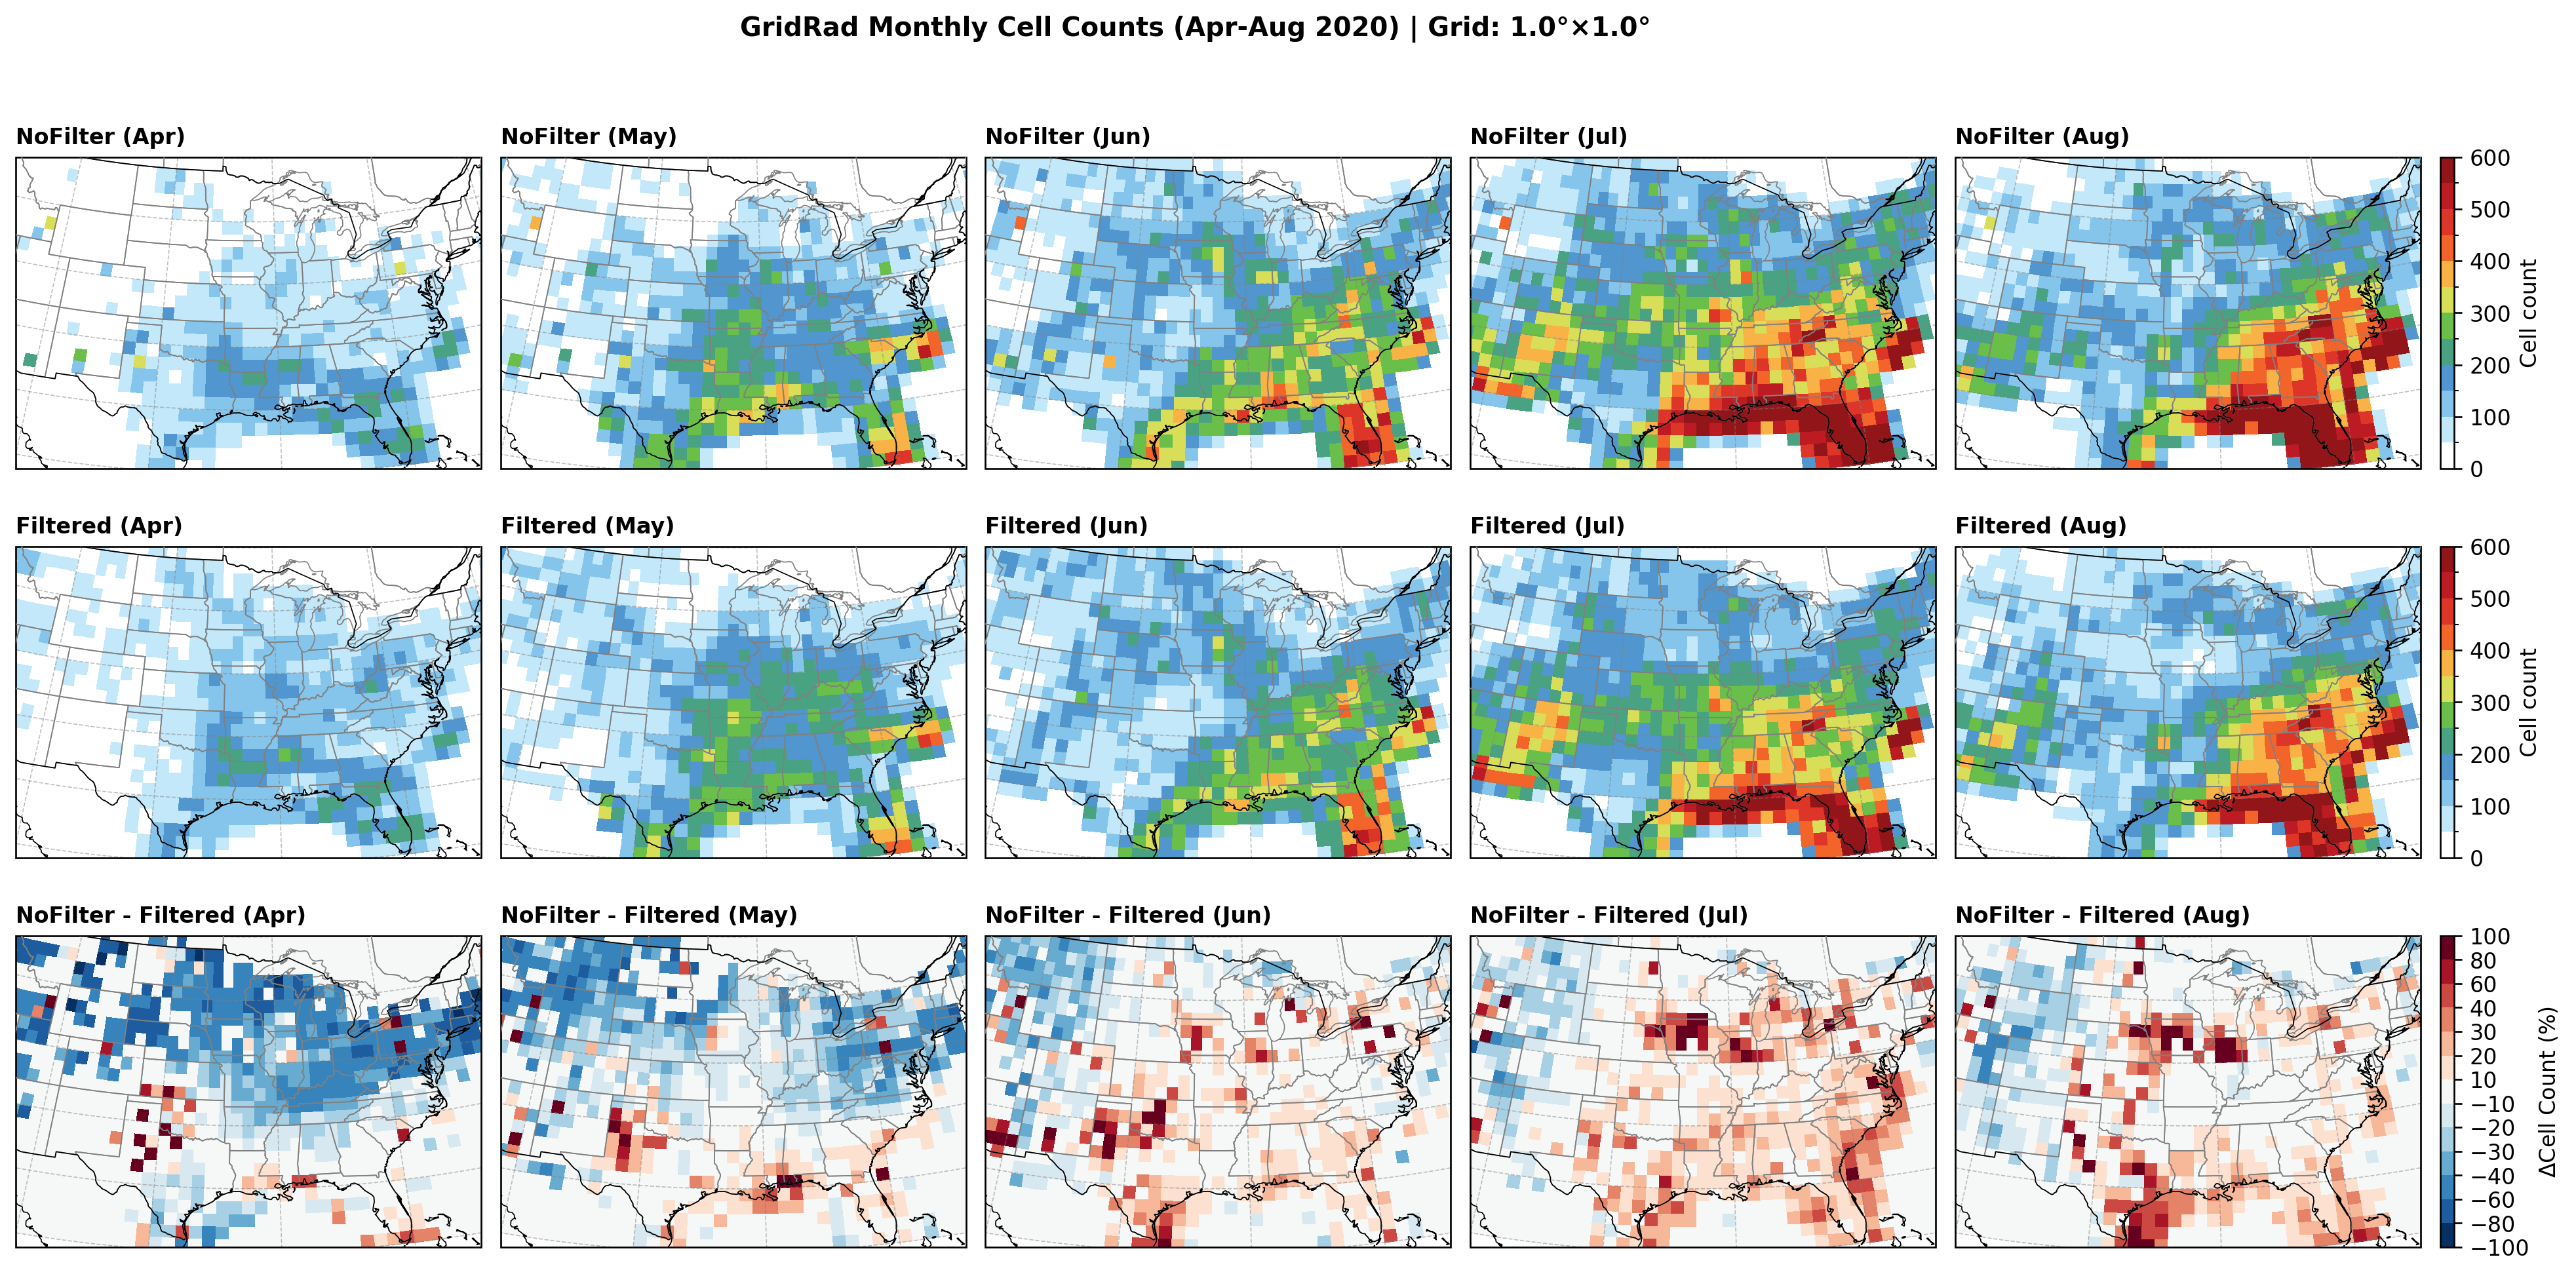

In [18]:
# Get month names for titles
month_names = {4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug'}

# Get available months
months = counts_s2.month.values
n_months = len(months)

# Layout: 3 rows x 5 columns
# Row 1: SCREAM - Apr, May, Jun, Jul, Aug
# Row 2: GridRad - Apr, May, Jun, Jul, Aug
# Row 3: Difference (SCREAM - GridRad) - Apr, May, Jun, Jul, Aug
nrow = 3
ncol = 5

map_extent_plt = [-110, -75, 25, 49]

# Prepare data arrays as nested list [row][col]
data_arrays = []
titles = []
cmaps = []
levels = []
cbar_labels = []

# Determine common color scale for SCREAM and GridRad
vmin_count = 0
vmax_count = 600
# vmax_count = max(float(counts_s2.max()), float(counts_s1.max()))

# Calculate difference for color scale
# diff_counts = counts_s1 - counts_s2
# Percentage difference
diff_counts = 100 * (counts_s1 - counts_s2) / counts_s2
min_count = 50
diff_counts = diff_counts.where(counts_s2 >= min_count, 0)  # mask out low-count grid boxes to avoid extreme percentage differences

# Choose colormaps
if colormaps is not None:
    cmap_count = colormaps.WhiteBlueGreenYellowRed
    cmap_diff = 'RdBu_r'
else:
    cmap_count = 'YlOrRd'
    cmap_diff = 'RdBu_r'

# Specify color levels
row_lev1 = np.arange(0, vmax_count+1, 50)
row_lev2 = row_lev1
# row_lev3 = np.arange(vmin_diff, vmax_diff+1, 200)
row_lev3 = [-100,-80,-60,-40,-30,-20,-10,10,20,30,40,60,80,100]
# row_lev3 = [-60,-40,-30,-20,-15,-10,-5,5,10,15,20,30,40,60]
levels = [
    [row_lev1]*ncol,
    [row_lev2]*ncol,
    [row_lev3]*ncol,
]
row_cbar_ticks1 = np.arange(0, vmax_count+1, 100)
row_cbar_ticks2 = row_cbar_ticks1
row_cbar_ticks3 = row_lev3
cbar_ticks = [
    [row_cbar_ticks1]*ncol,
    [row_cbar_ticks2]*ncol,
    [row_cbar_ticks3]*ncol,
]

# Row 1: SCREAM - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
# row_levels = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(counts_s1.sel(month=month).values)
    row_titles.append(f"{name_map['s1']} ({month_names[month]})")
    row_cmaps.append(cmap_count)
    # row_levels.append((vmin_count, vmax_count))
    row_cbar_labels.append('Cell count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
# levels.append(row_levels)
cbar_labels.append(row_cbar_labels)

# Row 2: GridRad - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
# row_levels = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(counts_s2.sel(month=month).values)
    row_titles.append(f"{name_map['s2']} ({month_names[month]})")
    row_cmaps.append(cmap_count)
    # row_levels.append((vmin_count, vmax_count))
    row_cbar_labels.append('Cell count')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
# levels.append(row_levels)
cbar_labels.append(row_cbar_labels)

# Row 3: Difference (SCREAM - GridRad) - Apr, May, Jun, Jul, Aug
row_data = []
row_titles = []
row_cmaps = []
# row_levels = []
row_cbar_labels = []

for month in [4, 5, 6, 7, 8]:
    row_data.append(diff_counts.sel(month=month).values)
    row_titles.append(f"{name_map['s1']} - {name_map['s2']} ({month_names[month]})")
    row_cmaps.append(cmap_diff)
    # row_levels.append((vmin_diff, vmax_diff))
    row_cbar_labels.append(f'$\\Delta$Cell Count (%)')

data_arrays.append(row_data)
titles.append(row_titles)
cmaps.append(row_cmaps)
# levels.append(row_levels)
cbar_labels.append(row_cbar_labels)

# Adjust figure size based on layout (3 rows x 5 columns)
fig_width = 4 * ncol
fig_height = 3 * nrow
print(f"Figure size: {fig_width} x {fig_height} inches")

fontsize = 10
figname = f'{figdir}Maps_MonthlyCellCount_{name_map["s1"]}_{name_map["s2"]}_Diff_{grid_res_x}x{grid_res_y}.png'

# Create the plot with one colorbar per row
fig, axes = plot_mxn_panels_lambert(
    nrow=nrow, ncol=ncol,
    data_arrays=data_arrays,
    lon_1d=counts_s2.longitude.values,
    lat_1d=counts_s2.latitude.values,
    cmaps=cmaps,
    levels=levels,
    titles=titles,
    cbar_labels=cbar_labels,
    figsize=(fig_width, fig_height),
    dpi=dpi,
    map_extent=map_extent_plt,
    suptitle=f"GridRad Monthly Cell Counts (Apr-Aug 2020) | Grid: {grid_res_x}°×{grid_res_y}°",
    wspace=0.05,
    hspace=0.25,
    fontsize=fontsize,
    map_resolution=map_resolution,
    cbar_mode='row',  # One colorbar per row
    cbar_ticks=cbar_ticks,  # Custom tick values for colorbars
    figname=figname
)


## Summary Statistics

In [15]:
# Calculate summary statistics
print("\n=== Summary Statistics ===")
print(f"\nGridRad:")
print(f"  Total cells (all months): {counts_s2.sum().values:,.0f}")
print(f"  Mean cells per grid box: {float(counts_s2.mean()):.1f}")
print(f"  Max cells per grid box: {float(counts_s2.max()):.0f}")

print(f"\nSCREAM:")
print(f"  Total cells (all months): {counts_s1.sum().values:,.0f}")
print(f"  Mean cells per grid box: {float(counts_s1.mean()):.1f}")
print(f"  Max cells per grid box: {float(counts_s1.max()):.0f}")

print(f"\nDifference (SCREAM - GridRad):")
print(f"  Mean difference: {float(diff_counts.mean()):.1f}")
print(f"  Total difference: {diff_counts.sum().values:,.0f}")

# Monthly totals
print("\n=== Monthly Totals ===")
print(f"{'Month':<10} {'GridRad':>12} {'SCREAM':>12} {'Difference':>12}")
print("-" * 50)
for month in months:
    total_s2 = counts_s2.sel(month=month).sum().values
    total_s1 = counts_s1.sel(month=month).sum().values
    diff = total_s1 - total_s2
    month_name = month_names[month]
    print(f"{month_name:<10} {total_s2:>12,.0f} {total_s1:>12,.0f} {diff:>12,.0f}")


=== Summary Statistics ===

GridRad:
  Total cells (all months): 738,254
  Mean cells per grid box: 98.4
  Max cells per grid box: 804

SCREAM:
  Total cells (all months): 766,799
  Mean cells per grid box: 102.2
  Max cells per grid box: 935

Difference (SCREAM - GridRad):
  Mean difference: inf
  Total difference: inf

=== Monthly Totals ===
Month           GridRad       SCREAM   Difference
--------------------------------------------------
Apr              82,632       65,186      -17,446
May             124,185      113,788      -10,397
Jun             147,157      157,302       10,145
Jul             203,571      231,866       28,295
Aug             180,709      198,657       17,948
